####**Telecom X - Análisis de Evasión de Clientes**

Has sido contratado como asistente de análisis de datos en Telecom X y formarás parte del proyecto "Churn de Clientes". La empresa enfrenta una alta tasa de cancelaciones y necesita comprender los factores que llevan a la pérdida de clientes.

Tu desafío será recopilar, procesar y analizar los datos, utilizando Python y sus principales bibliotecas para extraer información valiosa. A partir de tu análisis, el equipo de Data Science podrá avanzar en modelos predictivos y desarrollar estrategias para reducir la evasión.

In [33]:
import pandas as pd

In [34]:
datos=pd.read_json('/content/TelecomX_Data.json')
datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [31]:
import json

with open("TelecomX_Data.json") as f:
    data = json.load(f)

datos = pd.json_normalize(data, sep=".")

In [32]:
datos.shape

(7267, 21)

In [4]:
datos.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [5]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

####REVISANDO LAS INCONSISTENCIAS

In [6]:
datos.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [7]:
(datos == "").sum()

,0
customerID,0
Churn,224
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [8]:
datos.duplicated().sum()

np.int64(0)

In [9]:
datos["customerID"].duplicated().sum()

np.int64(0)

In [10]:
datos.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


In [12]:
datos["account.Charges.Total"] = pd.to_numeric(
    datos["account.Charges.Total"], errors="coerce"
)

In [14]:
datos["Churn"].unique()

array(['No', 'Yes', ''], dtype=object)

In [15]:
datos = datos[datos["Churn"] != ""]

In [16]:
(datos["Churn"] == "").sum()

np.int64(0)

Se identificaron 224 registros con valores vacíos en la columna Churn, que representa la variable objetivo del análisis. Debido a que no es posible determinar si estos clientes abandonaron o no el servicio, estos registros fueron eliminados del dataset para evitar inconsistencias en el análisis.

In [18]:
datos["account.Charges.Total"] = pd.to_numeric(
    datos["account.Charges.Total"], errors="coerce")

In [19]:
datos = datos.drop_duplicates()

In [20]:
datos.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [21]:
datos["account.Charges.Total"] = datos["account.Charges.Total"].fillna(0)

In [22]:
datos.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


Durante la revisión de valores faltantes se identificaron 11 valores nulos en la columna account.Charges.Total. Estos valores corresponden a clientes nuevos que aún no han acumulado cargos totales. Para mantener la consistencia del dataset, estos valores fueron reemplazados por 0.

##MANEJO DE INCONSISTENCIAS

In [23]:
datos["Churn"] = datos["Churn"].str.lower()

In [24]:
datos["Churn"] = datos["Churn"].replace({
    "yes": 1,
    "no": 0
})

/tmp/ipykernel_2396/360355231.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos["Churn"] = datos["Churn"].replace({


In [25]:
datos["Churn"].unique()

array([0, 1])

###Columna de cuentas diarias

In [28]:
datos["Cuentas_Diarias"] = (datos["account.Charges.Monthly"] / 30).round(2)

In [29]:
datos.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


Se creó la variable Cuentas_Diarias a partir de la facturación mensual (account.Charges.Monthly). Esta transformación permite analizar el gasto de los clientes en una escala diaria, facilitando comparaciones más precisas y una mejor comprensión del comportamiento de consumo.

####ANÁLISIS DESCRIPTIVO

In [35]:
datos.describe()

,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,9995-HOTOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


In [36]:
import pandas as pd
import json

with open("TelecomX_Data.json") as f:
    data = json.load(f)

datos = pd.json_normalize(data, sep=".")

In [37]:
datos.columns

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [38]:
datos.describe()

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
count,7267.000000,7267.000000,7267.000000
mean,0.162653,32.346498,64.720098
std,0.369074,24.571773,30.129572
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.425000
50%,0.000000,29.000000,70.300000
75%,0.000000,55.000000,89.875000
max,1.000000,72.000000,118.750000


In [39]:
datos.describe(include="object")

,customerID,Churn,customer.gender,customer.Partner,customer.Dependents,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Total
count,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267,7267
unique,7267,3,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531
top,9995-HOTOH,No,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2
freq,1,5174,3675,3749,5086,6560,3495,3198,3608,3182,3195,3582,2896,2870,4005,4311,2445,11


In [40]:
datos["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


In [41]:
datos["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,71.198569
Yes,25.719004
,3.082427


In [43]:
datos.groupby("Churn").mean(numeric_only=True)

,customer.SeniorCitizen,customer.tenure,account.Charges.Monthly
Churn,,,
,0.178571,31.571429,63.412277
No,0.128721,37.569965,61.265124
Yes,0.254682,17.979133,74.441332


El análisis comparativo entre clientes que permanecen y clientes que cancelan el servicio muestra diferencias importantes. Los clientes que abandonan la empresa presentan una antigüedad promedio significativamente menor, lo que indica que los usuarios más recientes tienen mayor probabilidad de cancelar el servicio. Además, estos clientes suelen tener cargos mensuales más altos, lo que podría sugerir que los planes más costosos están asociados con una mayor tasa de cancelación. Finalmente, se observa una mayor proporción de adultos mayores entre los clientes que cancelan el servicio.

In [44]:
pd.crosstab(datos["account.Contract"], datos["Churn"], normalize="index")

Churn,,No,Yes
account.Contract,,,
Month-to-month,0.032459,0.554307,0.413233
One year,0.030283,0.860434,0.109282
Two year,0.027539,0.944923,0.027539


El análisis de la tasa de cancelación según el tipo de contrato muestra una diferencia significativa entre los distintos planes. Los clientes con contratos mensuales presentan una tasa de churn considerablemente más alta, cercana al 41%, mientras que los contratos de un año reducen esta tasa a aproximadamente 11%. Por otro lado, los contratos de dos años muestran la menor tasa de cancelación, con apenas alrededor del 3%. Esto sugiere que la duración del contrato es uno de los factores más influyentes en la retención de clientes.

#####Recuento de evasión por variables categóricas

In [46]:
pd.crosstab(datos["customer.gender"], datos["Churn"], normalize="index")

Churn,,No,Yes
customer.gender,,,
Female,0.028953,0.709633,0.261414
Male,0.032653,0.714286,0.253061


El análisis de la tasa de cancelación según el género muestra que no existen diferencias significativas entre hombres y mujeres. Ambos grupos presentan porcentajes de churn muy similares, con aproximadamente un 26% de cancelación en mujeres y un 25% en hombres. Esto sugiere que el género no es un factor determinante en la decisión de los clientes de abandonar el servicio.

In [47]:
pd.crosstab(datos["account.PaymentMethod"], datos["Churn"], normalize="index")

Churn,,No,Yes
account.PaymentMethod,,,
Bank transfer (automatic),0.028320,0.809314,0.162366
Credit card (automatic),0.029337,0.822704,0.147959
Electronic check,0.032720,0.529243,0.438037
Mailed check,0.031832,0.783183,0.184985


El análisis del churn según el método de pago revela diferencias significativas entre los grupos. Los clientes que utilizan pagos automáticos, como transferencia bancaria o tarjeta de crédito, presentan las tasas más bajas de cancelación (entre 14% y 16%). En contraste, los clientes que pagan mediante cheque electrónico muestran la tasa de churn más alta, alcanzando aproximadamente el 44%. Esto sugiere que los métodos de pago automáticos podrían estar asociados a una mayor permanencia del cliente, mientras que el uso de cheque electrónico podría indicar menor compromiso con el servicio.

In [48]:
pd.crosstab(datos["internet.InternetService"], datos["Churn"], normalize="index")

Churn,,No,Yes
internet.InternetService,,,
DSL,0.026929,0.788585,0.184486
Fiber optic,0.031895,0.562539,0.405566
No,0.034788,0.893738,0.071474


El análisis del churn según el tipo de servicio de internet muestra diferencias significativas entre los clientes. Los usuarios de fibra óptica presentan la tasa de cancelación más alta, con aproximadamente un 40% de churn. En contraste, los clientes con DSL muestran una tasa de cancelación considerablemente menor (alrededor del 18%), mientras que los clientes sin servicio de internet presentan la tasa más baja, cercana al 7%. Esto sugiere que los clientes con fibra óptica podrían estar experimentando mayores niveles de insatisfacción o enfrentando costos más altos, lo que aumenta la probabilidad de cancelación.

####Distribución del tiempo con la empresa (tenure)

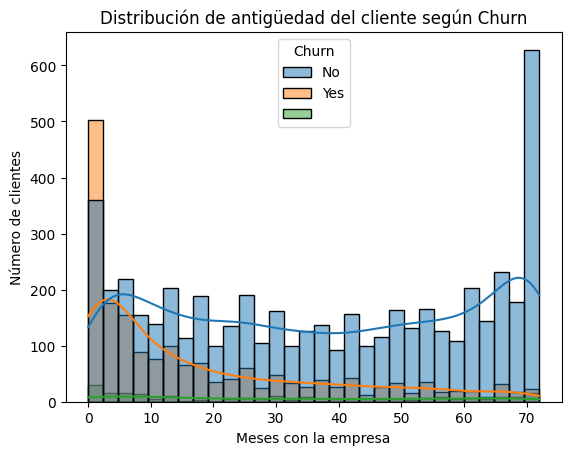

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=datos, x="customer.tenure", hue="Churn", bins=30, kde=True)

plt.title("Distribución de antigüedad del cliente según Churn")
plt.xlabel("Meses con la empresa")
plt.ylabel("Número de clientes")
plt.show()

Los clientes que cancelan el servicio suelen tener menor antigüedad en la empresa, lo que indica que el churn ocurre con mayor frecuencia en las primeras etapas de la relación con el cliente.

####**Distribución** de cargos mensuales

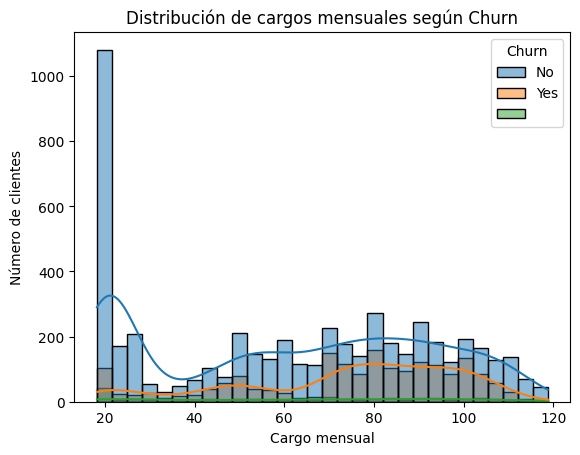

In [51]:
sns.histplot(data=datos, x="account.Charges.Monthly", hue="Churn", bins=30, kde=True)

plt.title("Distribución de cargos mensuales según Churn")
plt.xlabel("Cargo mensual")
plt.ylabel("Número de clientes")
plt.show()

Los clientes que presentan cargos mensuales más elevados tienden a cancelar el servicio con mayor frecuencia.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


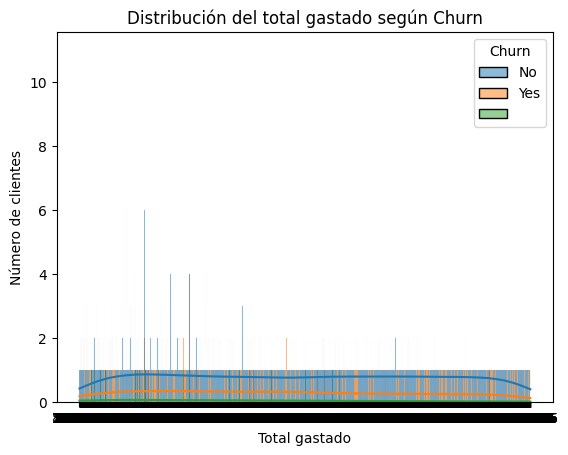

In [52]:
sns.histplot(data=datos, x="account.Charges.Total", hue="Churn", bins=30, kde=True)

plt.title("Distribución del total gastado según Churn")
plt.xlabel("Total gastado")
plt.ylabel("Número de clientes")
plt.show()

Los clientes que abandonan el servicio suelen presentar valores menores en el total gastado, lo que sugiere que la cancelación ocurre en etapas tempranas de la relación con la empresa.

El análisis de las variables numéricas muestra patrones claros en el comportamiento de los clientes. Los clientes que cancelan el servicio suelen tener menor antigüedad en la empresa y un menor total gastado, lo que sugiere que la evasión ocurre principalmente en las primeras etapas de la relación con el cliente. Además, se observa que los clientes con cargos mensuales más altos presentan una mayor tendencia a cancelar el servicio.

####INFORME FINAL

###INTRODUCCIÓN

La evasión de clientes (Churn) representa uno de los principales desafíos para las empresas de telecomunicaciones, ya que implica la pérdida de usuarios y una disminución en los ingresos recurrentes. Comprender los factores que influyen en la cancelación del servicio es fundamental para diseñar estrategias de retención efectivas.

El objetivo de este análisis es explorar y comprender los patrones asociados al churn, utilizando técnicas de análisis exploratorio de datos (EDA) para identificar variables que influyen en la probabilidad de cancelación del servicio.

####Limpieza y Preparación de los Datos

Antes de realizar el análisis, se llevó a cabo un proceso de preparación de los datos para garantizar su calidad y consistencia. Las principales acciones incluyeron:

Importación del dataset utilizando Pandas.

Exploración de la estructura del dataset y tipos de datos.

Revisión y manejo de valores faltantes.

Conversión de variables a formatos adecuados para el análisis.

Organización de variables numéricas y categóricas para facilitar el análisis exploratorio.

Este proceso permitió trabajar con un conjunto de datos limpio, consistente y listo para el análisis.

###Análisis Exploratorio de Datos (EDA)

El análisis exploratorio se centró en identificar patrones entre clientes que cancelaron el servicio (Churn = Yes) y aquellos que permanecieron (Churn = No).

Se analizaron tanto variables numéricas como variables categóricas mediante estadísticas descriptivas y visualizaciones.

**Variables** **Numéricas**

Se evaluaron variables como:

-Tiempo de permanencia del cliente (tenure)

-Cargo mensual (Monthly Charges)

-Total gastado por el cliente (Total Charges)

Los resultados muestran que:

Los clientes que cancelan suelen tener menor antigüedad en la empresa.

Los clientes con cargos mensuales más altos presentan mayor probabilidad de churn.

El total gastado es menor en clientes que cancelan, lo que sugiere que muchos abandonan el servicio en etapas tempranas.

Esto indica que los primeros meses de la relación con el cliente son críticos para su retención.

**Variables** **Categóricas**

El análisis también incluyó variables relacionadas con características del cliente y del servicio.

**Tipo de** **contrato**

Los clientes con contratos Month-to-month presentan las tasas de churn más altas, mientras que los contratos de uno o dos años muestran mayor retención.

**Método de pago**

El método Electronic Check está asociado con una tasa de cancelación significativamente mayor en comparación con métodos de pago automáticos como tarjeta de crédito o transferencia bancaria.

**Tipo de servicio de internet**

Los clientes que utilizan fibra óptica presentan una mayor tasa de churn en comparación con usuarios de DSL o clientes sin servicio de internet.

**Género**

No se encontraron diferencias significativas en la tasa de churn entre hombres y mujeres.

####Conclusiones e Insights

A partir del análisis exploratorio se identificaron varios factores clave asociados con la evasión de clientes:

-Los contratos mensuales presentan mayor riesgo de churn.

-Los clientes con menor tiempo de permanencia tienen mayor probabilidad de cancelar el servicio.

-El método de pago Electronic Check está asociado con tasas más altas de cancelación.

-Los clientes con servicio de fibra óptica presentan mayor churn.

-El género no influye significativamente en la cancelación del servicio.

Estos resultados permiten identificar segmentos de clientes con mayor riesgo de abandono, lo que facilita la implementación de estrategias de retención.

####Recomendaciones

Con base en los hallazgos obtenidos, se sugieren las siguientes acciones estratégicas:

-Promover contratos de mayor duración mediante incentivos o descuentos.

-Fomentar el uso de métodos de pago automáticos, que muestran menor tasa de cancelación.

-Implementar estrategias de fidelización en los primeros meses del cliente, etapa donde se concentra la mayor tasa de churn.

-Analizar la experiencia de clientes con fibra óptica para identificar posibles problemas de precio o calidad del servicio.

-Desarrollar modelos predictivos de churn, que permitan identificar clientes en riesgo y aplicar acciones preventivas.